PyTorch tutorial -
-  https://towardsdatascience.com/pytorch-introduction-tensors-and-tensor-calculations-412ff818bd5b
-  https://machinelearningmastery.com/training-a-linear-regression-model-in-pytorch/

Jupyter notebook -
- https://towardsdatascience.com/optimizing-jupyter-notebook-tips-tricks-and-nbextensions-26d75d502663

# Neural network with pyTorch

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time


![image.png](attachment:6254937f-5e7b-4be1-93e8-8fc067b762ac.png)

In [ ]:
layer = torch.nn.Linear(10, 20)

In [ ]:
layer

Linear(in_features=10, out_features=20, bias=True)

In [ ]:
n_samples = 40

In [ ]:
layer.weight.shape

torch.Size([20, 10])

In [ ]:
inp_2d = torch.rand(n_samples, 10)

In [ ]:
layer(inp_2d).shape

torch.Size([40, 20])

In [ ]:
inp_nd = torch.rand(n_samples, 3, 4, 5, 10)
layer(inp_nd).shape

torch.Size([40, 3, 4, 5, 20])

In [ ]:
layer.weight.shape

torch.Size([20, 10])

In [ ]:
(inp_nd @ layer.weight.T).shape

torch.Size([40, 3, 4, 5, 20])

## Fully connected NN

In [ ]:
import torch.nn as nn

class NNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(2,8)
        self.activation = nn.ReLU()
        self.output_layer = nn.Linear(8,1)
    def forward(self, x):
        x = self.input_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## The dataset

![image.png](attachment:87a41c61-2f31-47d7-9d48-d9d33dc62356.png)


In [ ]:
from torchvision import datasets

data_folder = 'fmnist/' # This can be any directory you want to download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.4MB/s]


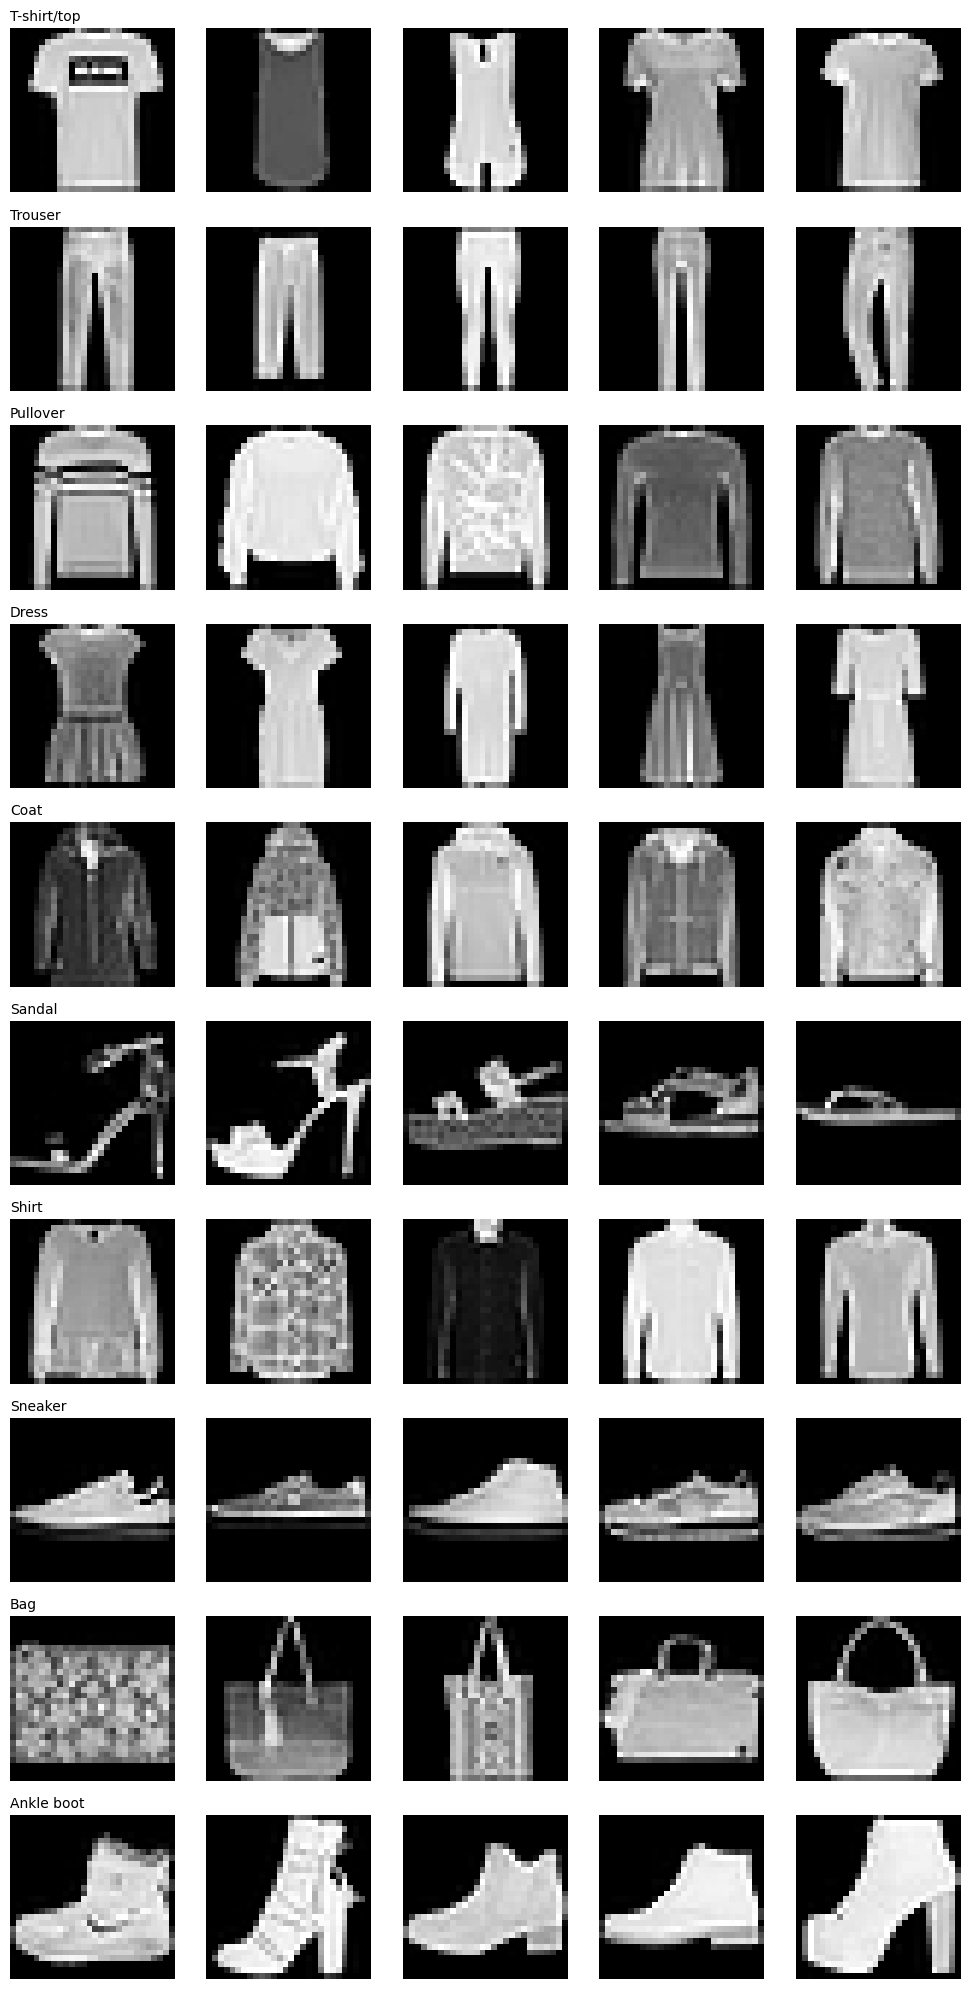

In [ ]:
# Class labels
class_names = fmnist.classes  # ['T-shirt/top', 'Trouser', ..., 'Ankle boot']

# Collect 5 samples per class
samples_per_class = 5
class_samples = {i: [] for i in range(10)}

for img, label in fmnist:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(img)
    if all(len(v) == samples_per_class for v in class_samples.values()):
        break

# Plot the grid
fig, axes = plt.subplots(10, samples_per_class, figsize=(samples_per_class * 2, 20))

for class_idx, images in class_samples.items():
    for i in range(samples_per_class):
        ax = axes[class_idx, i]
        ax.imshow(images[i], cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title(class_names[class_idx], fontsize=10, loc='left')

plt.tight_layout()
plt.show()


In [ ]:
fmnist

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: fmnist/
    Split: Train

In [ ]:
tr_images = fmnist.data  # [:10000]
tr_targets = fmnist.targets # [:10000]

In [ ]:
tr_targets.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
fmnist.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Text(0.5, 1.0, 'Bag')

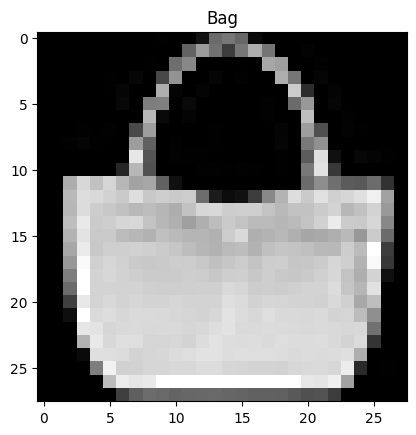

In [ ]:
k = 100
plt.figure()
plt.imshow(tr_images[k], cmap="gray")
plt.title(fmnist.classes[tr_targets[k]])


In [ ]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

In [ ]:
val_images.shape

torch.Size([10000, 28, 28])

In [ ]:
from torch.utils.data import Dataset, DataLoader

class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        # Repeat the single channel 3 times to match ResNet18 input
        x = x.view(-1, 1, 28, 28).float() / 255
        x = x.repeat(1, 3, 1, 1)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

In [ ]:
train = FMNISTDataset(tr_images, tr_targets)
trn_dl = DataLoader(train, batch_size=2, shuffle=True)

In [ ]:
train[0][0].shape

torch.Size([3, 28, 28])

In [ ]:
next(iter(trn_dl))

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0

# training

In [ ]:
# Hyper-parameters
EPOCHS = 50
BATCH_SIZE = 2048
LR = 1e-2
WD = 1e-6

In [ ]:
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # input to hidden
        self.fc2 = nn.Linear(128, 10)       # hidden to output (10 classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)           # flatten: (B, 1, 28, 28) -> (B, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
from torch.optim import SGD, AdamW
from torchvision import datasets, transforms

In [ ]:
def get_data():
    # train = FMNISTDataset(tr_images, tr_targets)
    # trn_dl = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
    # val = FMNISTDataset(val_images, val_targets)
    # val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    # return trn_dl, val_dl

    # Data augmentation for training
    train_transform = transforms.Compose([
        # transforms.RandomHorizontalFlip(p=0.5),
        # transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,))  # Fashion-MNIST specific normalization
    ])

    # Simple normalization for validation
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,))
    ])

    # Load datasets
    train_dataset = datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=train_transform)
    val_dataset = datasets.FashionMNIST(root='./data', train=False,
                                    download=True, transform=val_transform)

    # Data loaders
    trn_dl = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_dl = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False, num_workers=2)

    return trn_dl, val_dl


In [ ]:
from torch.optim import SGD, Adam
import torch.nn as nn

def get_model():
    # model = CNNModel().to(device)
    model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=False)
    # model = Model().to(device)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    num_ftrs = model.fc.in_features
    # Replace the fully connected layer with a new one that includes dropout
    model.fc = nn.Sequential(
        nn.Dropout(0.5), # Added dropout layer with a dropout rate of 0.5
        nn.Linear(num_ftrs, 10)
    )
    loss_fn = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    prediction = model(x)  # forawrd pass
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()  # backword pass
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item(), prediction # Return prediction as well

@torch.no_grad()
def accuracy(prediction, y): # Accept prediction as input
    # model.eval() # No need to call model.eval() here
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

In [ ]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()
model = model.to(device)

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
%%time
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_epoch_losses, train_epoch_accuracies = [], []
    model.train()  # Set model to training mode
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        x = x.to(device) # Move input data to the device
        y = y.to(device) # Move target data to the device
        batch_loss, prediction = train_batch(x, y, model, optimizer, loss_fn) # Get prediction from train_batch
        train_epoch_losses.append(batch_loss)

        is_correct = accuracy(prediction, y) # Use prediction as input
        train_epoch_accuracies.extend(is_correct)

    train_epoch_loss = np.array(train_epoch_losses).mean()
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    val_epoch_losses, val_epoch_accuracies = [], []
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
      for ix, batch in enumerate(iter(val_dl)):
          x, y = batch
          x = x.to(device) # Move input data to the device
          y = y.to(device) # Move target data to the device
          prediction = model(x) # Get prediction for validation
          val_is_correct = accuracy(prediction, y) # Use prediction as input
          val_epoch_accuracies.extend(val_is_correct)

          validation_batch_loss = loss_fn(prediction, y).item() # Use loss_fn directly
          val_epoch_losses.append(validation_batch_loss)
    val_epoch_loss = np.array(val_epoch_losses).mean()
    val_epoch_accuracy = np.mean(val_epoch_accuracies)

    end_time = time.time()
    epoch_time = end_time - start_time

    print(f"Epoch {epoch+1}/{EPOCHS}, Time: {epoch_time:.2f}s, Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.4f}")


    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)

Epoch 1/50, Time: 23.04s, Train Loss: 1.6736, Train Acc: 0.4861, Val Loss: 2.4290, Val Acc: 0.5296
Epoch 2/50, Time: 21.92s, Train Loss: 0.6953, Train Acc: 0.7374, Val Loss: 0.6305, Val Acc: 0.7568
Epoch 3/50, Time: 21.46s, Train Loss: 0.5660, Train Acc: 0.7848, Val Loss: 0.5112, Val Acc: 0.7994
Epoch 4/50, Time: 22.91s, Train Loss: 0.4956, Train Acc: 0.8140, Val Loss: 0.4569, Val Acc: 0.8302
Epoch 5/50, Time: 22.41s, Train Loss: 0.4425, Train Acc: 0.8344, Val Loss: 0.4504, Val Acc: 0.8318
Epoch 6/50, Time: 21.74s, Train Loss: 0.4073, Train Acc: 0.8466, Val Loss: 0.3811, Val Acc: 0.8520
Epoch 7/50, Time: 21.46s, Train Loss: 0.3677, Train Acc: 0.8620, Val Loss: 0.3481, Val Acc: 0.8690
Epoch 8/50, Time: 22.49s, Train Loss: 0.3505, Train Acc: 0.8691, Val Loss: 0.3202, Val Acc: 0.8826
Epoch 9/50, Time: 21.91s, Train Loss: 0.3348, Train Acc: 0.8748, Val Loss: 0.4507, Val Acc: 0.8458
Epoch 10/50, Time: 21.54s, Train Loss: 0.3165, Train Acc: 0.8816, Val Loss: 0.3735, Val Acc: 0.8602
Epoch 11/

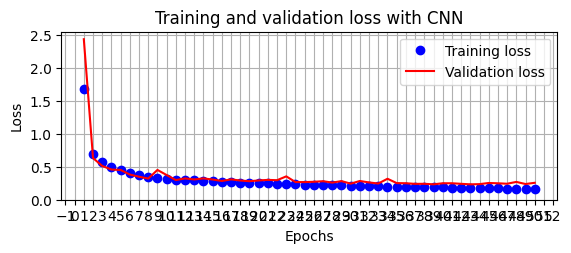

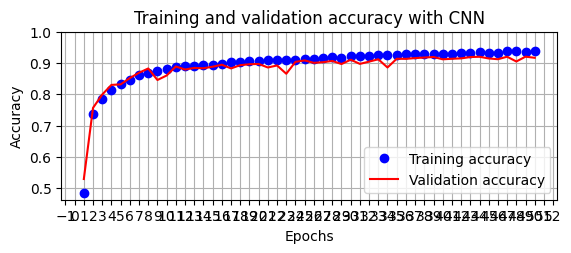

In [ ]:
epochs = np.arange(EPOCHS)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with CNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0,None)
plt.legend()
plt.grid('off')
plt.show()
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with CNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(None,1.0)
# plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')
plt.show()

In [ ]:
model

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
next(model.parameters()).device

device(type='cuda', index=0)

In [ ]:
x_batch, y_batch = next(iter(trn_dl))

In [ ]:
model = model.to(device)

In [ ]:
model(x)

probs = F.softmax(model(x), dim=1)

torch.set_printoptions(threshold=float('inf'), edgeitems=20, linewidth=200, precision=3, sci_mode=False)
print(probs)

tensor([[    0.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.999],
        [    0.000,     0.000,     0.998,     0.000,     0.001,     0.000,     0.001,     0.000,     0.000,     0.000],
        [    0.000,     1.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000],
        [    0.000,     1.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000],
        [    0.411,     0.000,     0.019,     0.004,     0.004,     0.000,     0.562,     0.000,     0.000,     0.000],
        [    0.000,     0.999,     0.000,     0.001,     0.000,     0.000,     0.000,     0.000,     0.000,     0.000],
        [    0.000,     0.000,     0.110,     0.000,     0.886,     0.000,     0.003,     0.000,     0.000,     0.000],
        [    0.000,     0.000,     0.022,     0.000,     0.744,     0.000,     0.234,     0.000,     0.000,     0.000],
        [    0.000,     0.000,     0.000

# performance evaluation

In [ ]:
val_images.shape

torch.Size([10000, 28, 28])

In [ ]:
logits = model(val_images[:,None, :,:].to(device).float()/255)

In [ ]:
logits = logits.cpu().detach()

In [ ]:
softmax= nn.Softmax(dim=1)

In [ ]:
y_probs = softmax(logits)

In [ ]:
y_probs.shape

torch.Size([10000, 10])

In [ ]:
val_targets.shape


torch.Size([10000])

In [ ]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(val_targets)
y_onehot_val = label_binarizer.transform(val_targets)

In [ ]:
y_onehot_val

array([[0, 0, 0, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

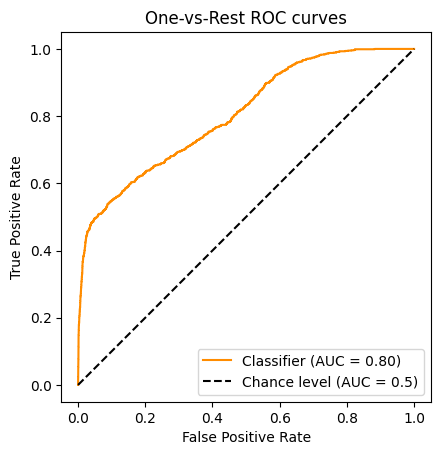

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay

class_id = 0
RocCurveDisplay.from_predictions(
    y_onehot_val[:, class_id],
    y_probs[:, class_id],
    color="darkorange",
    plot_chance_level=True,
)
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
X_actual = [1, 1, 0, 1, 0, 0, 1, 0, 0, 0]
Y_predic = [1, 0, 1, 1, 1, 0, 1, 1, 0, 0]
X_actual = y_onehot_val.argmax(axis=1)
Y_predic = y_probs.argmax(axis=1)
results = confusion_matrix(X_actual, Y_predic)
print ('Confusion Matrix :')
print(results)
print ('Accuracy Score is',accuracy_score(X_actual, Y_predic))
print ('Classification Report : ')
print (classification_report(X_actual, Y_predic))
print('AUC-ROC:',roc_auc_score(y_onehot_val.ravel(), y_probs.ravel()))
print('LOGLOSS Value is',log_loss(y_onehot_val.ravel(), y_probs.ravel()))

Confusion Matrix :
[[ 98   0 871   0   0   0  27   0   4   0]
 [  0 552 152  43   0   0 253   0   0   0]
 [  0   0 988   0   0   0  12   0   0   0]
 [  3   0 703  18   0   0 275   0   1   0]
 [  0   0 934   1   1   0  64   0   0   0]
 [  0   0 675   6   0   0  13   0 304   2]
 [ 13   0 802   0   0   0 176   0   9   0]
 [  0   0 262 101   0   0  17   0 523  97]
 [  0   0 413   1   0   0  85   0 501   0]
 [  0   0 135   7   0   0 198   0  57 603]]
Accuracy Score is 0.2937
Classification Report : 
              precision    recall  f1-score   support

           0       0.86      0.10      0.18      1000
           1       1.00      0.55      0.71      1000
           2       0.17      0.99      0.28      1000
           3       0.10      0.02      0.03      1000
           4       1.00      0.00      0.00      1000
           5       0.00      0.00      0.00      1000
           6       0.16      0.18      0.17      1000
           7       0.00      0.00      0.00      1000
           8 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_probs.argmax(axis=1)

tensor([2, 2, 1, 1, 6, 2, 2, 6, 8, 8, 2, 2, 8, 6, 2, 3, 2, 2, 2, 2, 2, 8, 8, 8, 6, 2, 2, 2, 9, 2, 8, 2, 3, 2, 2, 2, 8, 2, 8, 9, 2, 1, 2, 9, 2, 2, 2, 2, 2, 2, 2, 2, 2, 8, 2, 2, 8, 6, 8, 2, 2, 8, 8, 2,
        1, 6, 2, 2, 2, 2, 3, 2, 2, 2, 2, 6, 1, 2, 8, 2, 6, 8, 2, 9, 8, 0, 2, 2, 2, 2, 2, 6, 2, 8, 1, 8, 2, 6, 2, 2, 2, 2, 2, 2, 8, 2, 8, 8, 6, 2, 2, 8, 8, 2, 2, 2, 8, 6, 8, 8, 2, 2, 6, 9, 0, 0, 8, 2,
        6, 2, 2, 1, 8, 2, 8, 2, 2, 1, 2, 2, 1, 6, 2, 2, 1, 2, 6, 2, 2, 2, 2, 6, 6, 2, 8, 2, 2, 8, 9, 2, 3, 2, 6, 6, 2, 9, 2, 8, 2, 2, 2, 2, 2, 1, 2, 6, 2, 2, 9, 1, 2, 9, 2, 8, 8, 9, 9, 2, 2, 8, 2, 2,
        6, 2, 2, 2, 8, 2, 2, 1, 1, 2, 2, 6, 2, 2, 2, 8, 9, 2, 2, 6, 2, 2, 1, 6, 2, 2, 8, 2, 8, 2, 2, 2, 8, 8, 2, 2, 2, 2, 3, 8, 9, 2, 9, 2, 2, 6, 2, 2, 2, 6, 9, 2, 2, 8, 6, 2, 2, 2, 2, 8, 2, 8, 2, 2,
        2, 8, 2, 2, 2, 2, 8, 2, 2, 2, 2, 8, 9, 6, 1, 2, 2, 2, 2, 0, 8, 2, 3, 2, 2, 6, 6, 2, 2, 2, 2, 8, 2, 2, 8, 9, 8, 6, 8, 8, 2, 9, 8, 2, 2, 2, 2, 8, 2, 2, 2, 9, 8, 9, 1, 6, 6, 2, 2, 2, 9, 1, 2, 2,


In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for each class
n_classes = 10
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, cls in enumerate(fmnist.classes):
    fpr[i], tpr[i], _ = roc_curve(val_targets==i, y_probs[:, i])
    roc_auc[cls] = auc(fpr[i], tpr[i])

In [ ]:
roc_auc

{'T-shirt/top': np.float64(0.8046215555555556),
 'Trouser': np.float64(0.9579303333333334),
 'Pullover': np.float64(0.9059178333333333),
 'Dress': np.float64(0.6254599999999999),
 'Coat': np.float64(0.3980932222222222),
 'Sandal': np.float64(0.7701195555555556),
 'Shirt': np.float64(0.6491081111111112),
 'Sneaker': np.float64(0.9189629444444444),
 'Bag': np.float64(0.7821028888888889),
 'Ankle boot': np.float64(0.9713329999999999)}

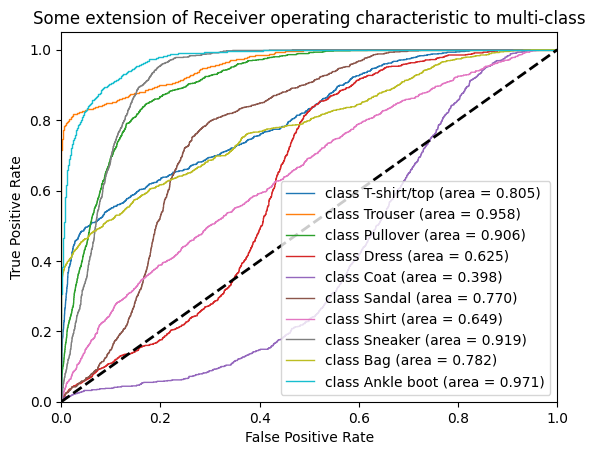

In [ ]:
plt.figure()
for i, cls in enumerate(fmnist.classes):
    plt.plot(fpr[i], tpr[i], lw=1,
             label='class {0} (area = {1:0.3f})'
             ''.format(cls, roc_auc[cls]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

In [ ]:
np.printoptions(precision=2, linewidth=150)

In [ ]:
with np.printoptions(precision=3, linewidth=150, edgeitems=5):
    print(softmax(logits).numpy())

[[4.489e-02 1.982e-02 3.291e-01 5.570e-02 3.182e-02 2.270e-02 2.693e-01 1.432e-02 2.213e-02 1.901e-01]
 [7.811e-04 1.260e-06 9.918e-01 2.597e-05 6.097e-04 4.666e-06 6.754e-03 8.391e-07 1.926e-05 1.321e-06]
 [1.617e-02 6.969e-01 7.111e-02 8.189e-02 3.750e-02 1.331e-03 9.139e-02 5.353e-04 1.227e-03 1.907e-03]
 [5.118e-02 5.212e-01 9.402e-02 2.214e-01 3.050e-02 1.961e-03 7.441e-02 8.634e-04 2.401e-03 2.084e-03]
 [1.422e-02 5.282e-05 3.720e-01 7.169e-04 2.784e-03 1.727e-04 6.098e-01 3.469e-05 2.155e-04 7.308e-05]
 ...
 [4.474e-02 5.002e-02 1.432e-01 6.740e-02 2.206e-02 3.966e-02 1.861e-01 2.483e-02 5.401e-02 3.680e-01]
 [4.531e-02 1.075e-02 1.494e-01 1.706e-01 3.295e-02 6.294e-04 5.879e-01 4.384e-04 1.064e-03 9.291e-04]
 [8.515e-03 4.506e-05 8.173e-01 8.979e-04 6.540e-03 1.210e-04 1.663e-01 3.529e-05 2.250e-04 5.644e-05]
 [3.493e-02 1.812e-01 6.803e-02 2.657e-01 4.073e-02 7.846e-04 4.047e-01 5.876e-04 1.448e-03 1.896e-03]
 [9.903e-03 1.330e-03 8.498e-01 2.872e-02 2.697e-02 4.353e-04 8.135e

In [ ]:
prob = softmax(logits).numpy()

In [ ]:
prob.sum(axis=1)

array([1.       , 1.0000001, 0.9999998, ..., 0.9999999, 0.9999999,
       1.       ], dtype=float32)

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute ROC curve and ROC area for each class
n_classes = 10
precision = dict()
recall = dict()
pr_average = dict()

for i, cls in enumerate(fmnist.classes):
    precision[i], recall[i], _ = precision_recall_curve(val_targets==i, y_probs[:, i])
    pr_average[cls] = average_precision_score(val_targets==i, y_probs[:, i])

In [ ]:
pr_average

{'T-shirt/top': np.float64(0.5091124822301806),
 'Trouser': np.float64(0.8750203899975841),
 'Pullover': np.float64(0.5123950097330288),
 'Dress': np.float64(0.12957374023500273),
 'Coat': np.float64(0.0828652394978051),
 'Sandal': np.float64(0.1987839616688516),
 'Shirt': np.float64(0.18057607858315305),
 'Sneaker': np.float64(0.44306354339264703),
 'Bag': np.float64(0.5476317721945013),
 'Ankle boot': np.float64(0.8383680409662873)}

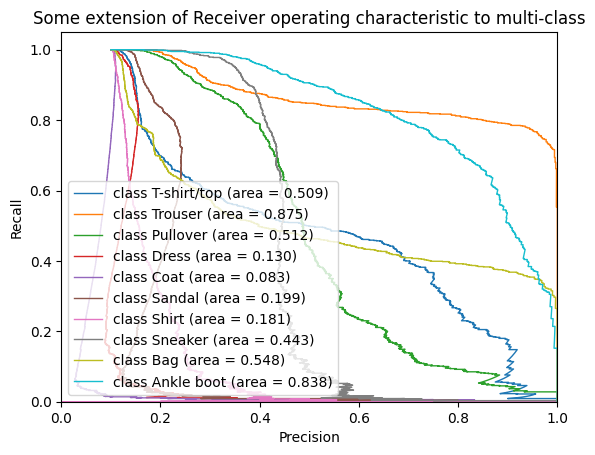

In [ ]:
plt.figure()
for i, cls in enumerate(fmnist.classes):
    plt.plot(precision[i], recall[i], lw=1,
             label='class {0} (area = {1:0.3f})'
             ''.format(cls, pr_average[cls]))

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower left")
plt.show()

In [ ]:
@torch.no_grad()
def val_loss(prediction, y): # Accept prediction as input
    # model.eval() # No need to call model.eval() here
    val_loss = loss_fn(prediction, y)
    return val_loss.item()